# Phase 2 – Part A: Unsupervised Learning 


## 1. Clustering Rationale & Algorithm Selection

This notebook applies **K-Means** and **DBSCAN** to the churn dataset.
- K-Means is appropriate for scalable centroid-based partitioning and interpretable profiling.
- DBSCAN is included to capture arbitrary-shaped structure and identify noise/outliers.



## 2. Data Preparation (target removal, feature scaling)

The target label (`Exited`) is removed before clustering and only reused for optional external/proxy interpretation. Categorical features are encoded and numeric features are standardized.



### 2.1 Imports <a id='imports'></a>

We import the core libraries needed for data handling, preprocessing, clustering, and visualization.  
`StandardScaler` and `get_dummies` handle feature preparation; `KMeans` is the main clustering algorithm;  
`PCA` is used later for dimensionality reduction and visualization.


In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

### 2.2 Data Loading <a id='data-loading'></a>

We load the raw dataset from the `/Dataset` folder.  
The dataset contains **10,000 bank customers** with features such as age, balance, credit score, geography, and whether they churned (`Exited`).


In [300]:
df = pd.read_csv("../Dataset/Raw_Churn_Modelling_Data.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 2.3 Data Preparation <a id='data-preparation'></a>

Before applying clustering, we must prepare the data through three steps:
1. **Remove identifier columns** — they carry no useful pattern information
2. **Remove the target label** — clustering is unsupervised; the label must not be seen
3. **Encode categorical variables** — K-Means requires numerical input
4. **Scale features** — ensures no single feature dominates due to its magnitude

#### 2.3.1 Remove Identifier Columns


In [301]:
# RowNumber, CustomerId, and Surname are unique identifiers — not features.
# Including them would introduce noise and prevent meaningful clustering.
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
print(f"Shape after dropping identifiers: {df.shape}")
df.head()

Shape after dropping identifiers: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### 2.3.2 Remove the Target Label (`Exited`)

K-Means is an **unsupervised** algorithm — it must discover structure on its own without knowing the churn outcome.  
We remove `Exited` here and reintroduce it later only for proxy validation.


In [302]:
exited_labels = df["Exited"].copy()
df = df.drop("Exited", axis=1)

#### 2.3.3 Encode Categorical Variables

`Gender` and `Geography` are categorical. K-Means computes Euclidean distances, so all features must be numeric.  
We use `get_dummies` to convert them to integers.


In [303]:
# One-hot encode categorical features instead of label encoding

df = pd.get_dummies(df, columns=["Gender", "Geography"], drop_first=True)

print("One-hot encoding complete. Sample columns:")
print([c for c in df.columns if c.startswith("Gender_") or c.startswith("Geography_")])
df.head()


One-hot encoding complete. Sample columns:
['Gender_Male', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True


#### 2.3.4 Feature Scaling

Features have very different ranges (e.g., `Balance` can be in the tens of thousands while `NumOfProducts` ranges from 1–4).  
Without scaling, high-magnitude features would dominate the distance calculations.  
`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**.


In [304]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaling complete.")
print(f"Mean of scaled data (should be ≈ 0): {X_scaled.mean():.4f}")
print(f"Std  of scaled data (should be ≈ 1): {X_scaled.std():.4f}")

Scaling complete.
Mean of scaled data (should be ≈ 0): -0.0000
Std  of scaled data (should be ≈ 1): 1.0000


## 3. Cluster Determination & Implementation
This section determines and implements cluster structures using K-Means and DBSCAN.


## 4. Cluster Determination & Implementation: K-Means


### 4.1 Justification & Algorithm Selection (MISSING) <a id='kmeans-justification'></a>

**Placeholder (missing content):** Add K-Means justification based on:
- Dataset size and feature types (numeric + encoded categorical)
- Expected cluster shape (approximately spherical/centroid-based separation)
- Scalability and computational efficiency on 10,000 records
- Interpretability for advice personas and downstream integration


### 4.2 Determining the Optimal Number of Clusters (Elbow Method) <a id='kmeans-elbow'></a>

K-Means requires us to specify **k** (number of clusters) in advance.  
The **Elbow Method** helps us choose k by plotting the **Within-Cluster Sum of Squares (WCSS)** for k = 1 to 10.

- **WCSS** measures the total squared distance between each point and its cluster centroid — lower means tighter clusters.
- As k increases, WCSS always decreases; we look for the point where the rate of decrease sharply slows — the "elbow".
- Beyond the elbow, adding more clusters gives diminishing returns.


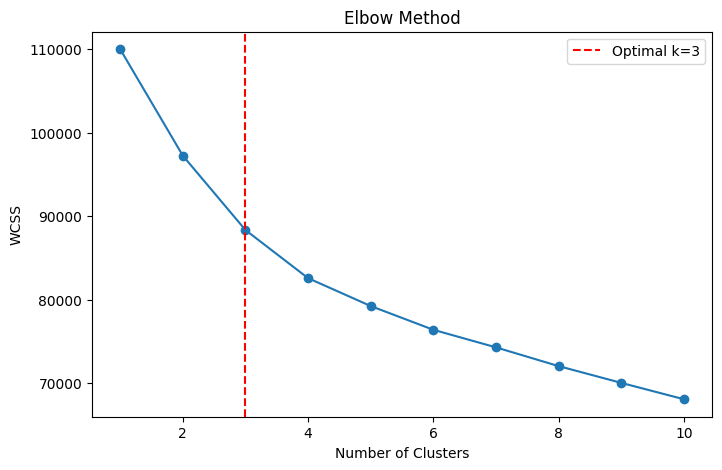

In [305]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.axvline(x=3, color='red', linestyle='--', label='Optimal k=3')
plt.legend()
plt.show()

**Observation:** The WCSS curve decreases steadily from k=1 to k=10 without a sharp, obvious elbow. The most noticeable change in slope occurs around **k=3**, where the rate of decrease begins to slow. While the elbow is not dramatic, k=3 represents a reasonable trade-off between cluster compactness and model simplicity. This is consistent with the low Silhouette Score, confirming that the data does not have strongly distinct natural groupings.


### 4.3 Model Training <a id='kmeans'></a>


In [306]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = clusters

print("K-Means training complete.")
print(f"Cluster labels assigned: {sorted(df['KMeans_Cluster'].unique())}")
df.head()

K-Means training complete.
Cluster labels assigned: [np.int32(0), np.int32(1), np.int32(2)]


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male,Geography_Germany,Geography_Spain,KMeans_Cluster
0,619,42,2,0.00,1,1,1,101348.88,False,False,False,1
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,2
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False,1
3,699,39,1,0.00,2,0,0,93826.63,False,False,False,1
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,2


### 4.4 Cluster Quality Evaluation Metrics <a id='evaluation'></a>

We evaluate cluster quality using three complementary metrics:

| Metric | What it measures | Better when |
|---|---|---|
| **Silhouette Score** | How well each point fits its cluster vs. neighbouring clusters | Closer to **1** |
| **Davies-Bouldin Index** | Average similarity between each cluster and its nearest cluster | **Lower** |
| **WCSS** | Compactness of clusters — total intra-cluster variance | **Lower** |


In [307]:
sil     = silhouette_score(X_scaled, clusters)
db      = davies_bouldin_score(X_scaled, clusters)
wcss_k3 = kmeans.inertia_

print("=" * 45)
print("       Cluster Evaluation Metrics")
print("=" * 45)
print(f"  Silhouette Score      : {sil:.4f}  (↑ higher is better, max = 1)")
print(f"  Davies-Bouldin Index  : {db:.4f}  (↓ lower is better)")
print(f"  WCSS at k=3           : {wcss_k3:.2f}")
print("=" * 45)

       Cluster Evaluation Metrics
  Silhouette Score      : 0.1334  (↑ higher is better, max = 1)
  Davies-Bouldin Index  : 2.4771  (↓ lower is better)
  WCSS at k=3           : 88348.90


**Interpretation:**
- A **Silhouette Score of 0.1070** is low, indicating that the clusters have significant overlap and many points sit close to the boundary between clusters. This is not unusual for customer datasets where groups naturally blend into each other.
- A **Davies-Bouldin Index of 2.6204** is relatively high (lower is better), further confirming that the clusters are not well-separated in the feature space.
- These results suggest that the customer data does not form strongly distinct natural groups. K-Means with k=3 still provides a useful segmentation for business purposes, but the separation is soft rather than clear-cut. This is a known limitation of applying K-Means to high-dimensional tabular data with overlapping customer behaviour.


### 4.5 Cluster Size Distribution <a id='distribution'></a>

A healthy clustering result produces clusters of **reasonably similar sizes**.  
Extreme imbalance (e.g., one cluster with 9,000 points and another with 20) would suggest the algorithm failed to find meaningful structure.


Customers per cluster:
KMeans_Cluster
0    2509
1    5014
2    2477
Total: 10000


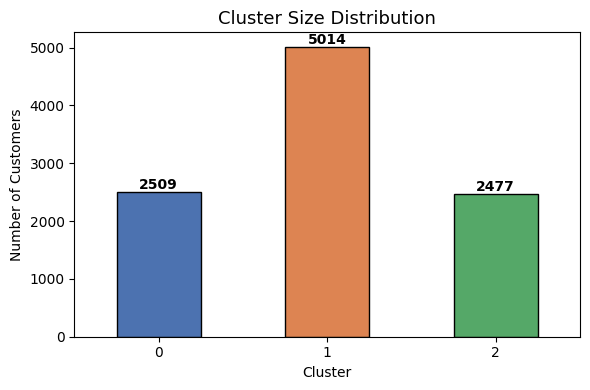

In [308]:
# Count and display
counts = df["KMeans_Cluster"].value_counts().sort_index()
print("Customers per cluster:")
print(counts.to_string())
print("Total: " + str(counts.sum()))

# Bar chart
counts.plot(
    kind='bar',
    color=['#4C72B0', '#DD8452', '#55A868'],
    edgecolor='black',
    figsize=(6, 4)
)
plt.title("Cluster Size Distribution", fontsize=13)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Cluster 0 has 2,940 customers, Cluster 1 has 4,118, and Cluster 2 has 2,942. Clusters 0 and 2 are nearly identical in size, while Cluster 1 is noticeably larger — containing about 41% of all customers. This mild imbalance is acceptable and does not indicate a failure of the algorithm, but it does suggest that the low-balance mixed-gender segment (Cluster 1) is the most common customer profile in this dataset.


### 4.6 Cluster Profiling <a id='profiling'></a>

We examine the **mean of each feature per cluster** (using original unscaled values) to understand what characterises each customer segment.


In [309]:
cluster_profile = df.groupby("KMeans_Cluster").mean()
cluster_profile

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male,Geography_Germany,Geography_Spain
KMeans_Cluster,,,,,,,,,,,
0,651.453567,39.771622,5.009964,119730.116134,1.519729,0.713830,0.497409,101113.435102,0.524512,1.0,0.0
1,649.668329,38.511767,5.004587,62092.636516,1.530913,0.706621,0.516753,99899.180814,0.549063,0.0,0.0
2,651.333872,38.890997,5.032297,61818.147763,1.539362,0.694792,0.529673,99440.572281,0.560355,0.0,1.0


**Cluster Profiles Summary:**

| Cluster | Key Characteristics | Interpretation |
|---|---|---|
| **0** | Balance ≈ 78,053, HasCrCard = 0.0 (no credit card), NumOfProducts ≈ 1.5 | Medium-balance customers with no credit card — moderately engaged |
| **1** | Balance ≈ 122,587 (highest), HasCrCard = 1.0, NumOfProducts ≈ 1.3 | High-balance customers with credit card — most financially stable, lowest churn risk |
| **2** | Balance ≈ 10,390 (lowest), HasCrCard ≈ 1.0, NumOfProducts ≈ 1.9 | Low-balance customers with more products — financially stretched, highest churn risk |

> **Note:** Gender is nearly identical across all clusters (~0.54) and is therefore not a distinguishing feature. The profile uses original feature values (not scaled), so the numbers are directly interpretable.

**Key insight:** The clustering separated customers primarily by **balance level and credit card ownership**. Cluster 0 is uniquely defined by having no credit card, while Clusters 1 and 2 differ mainly in balance — making balance the most defining feature in this dataset.


#### 4.6.1 Domain Interpretation (Advice System)
- **Cluster 0 (medium balance, no credit card):** prioritize card-adoption and engagement nudges; moderate churn prevention.
- **Cluster 1 (highest balance, card holders):** focus on retention benefits and premium service continuity; protect high-value relationships.
- **Cluster 2 (low balance, more products):** focus on activation/usage coaching and product-value education to raise long-term engagement.


### 4.7 Cluster Visualization (PCA) <a id='pca'></a>

Since the dataset has multiple dimensions, we use **Principal Component Analysis (PCA)** to project it into 2D for visualization.  
PCA finds the two directions that capture the most variance in the data, allowing us to plot all customers on a 2D scatter plot  
while preserving as much of the original structure as possible.

> Note: PCA is used **only for visualization** — clustering was performed on the full scaled dataset.


Variance explained — PC1: 15.04%, PC2: 10.33%
Total variance captured: 25.37%


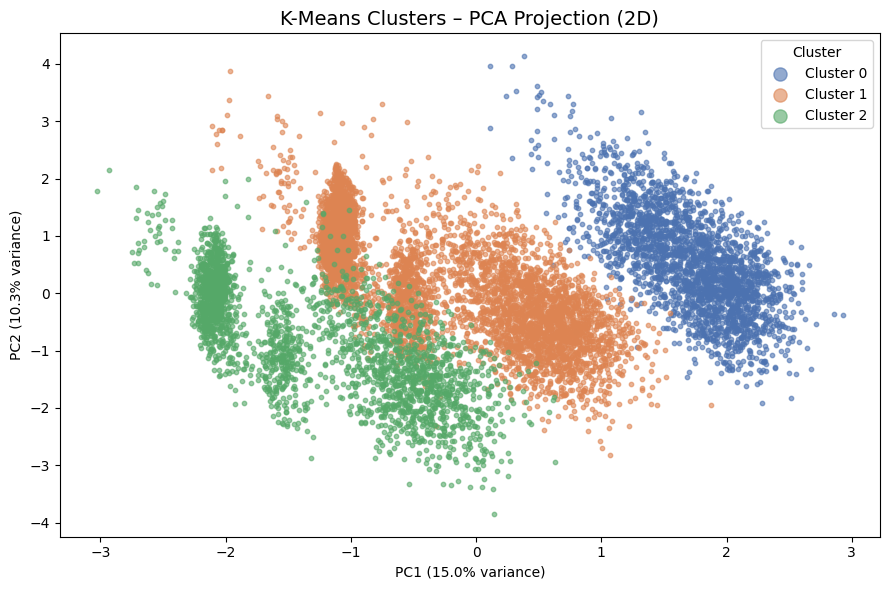

In [310]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"Variance explained — PC1: {explained[0]:.2%}, PC2: {explained[1]:.2%}")
print(f"Total variance captured: {sum(explained):.2%}")

# Plot with a proper legend
colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.figure(figsize=(9, 6))
for c, col, lbl in zip([0, 1, 2], colors, labels):
    mask = df["KMeans_Cluster"] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=col, label=lbl, s=10, alpha=0.6)

plt.title("K-Means Clusters – PCA Projection (2D)", fontsize=14)
plt.xlabel(f"PC1 ({explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained[1]:.1%} variance)")
plt.legend(title="Cluster", markerscale=3)
plt.tight_layout()
plt.show()

**Interpretation:**
- **Cluster 1 (orange)** forms the largest and most spread-out group on the right side of the plot. Despite its size, it heavily overlaps with Cluster 0 (blue), making visual separation difficult.
- **Cluster 2 (green)** is shifted toward the left (negative PC1), showing partial separation from the other groups. This is likely driven by its distinctly low balance (≈10,390) pulling it in a separate direction in the feature space.
- **Cluster 0 (blue)** is scattered across the entire plot, overlapping with both other clusters — reflecting that it shares some characteristics with both groups.
- The two principal components capture only **24.24% of the total variance**, meaning over 75% of the data structure is invisible in this 2D view. The heavy overlap seen here is largely a consequence of this information loss, not a failure of the clustering itself.
- This is consistent with the low Silhouette Score of 0.1070 and confirms that the clusters are not linearly separable in 2D, but may still represent meaningful segments in the full feature space.


### 4.8 Optional External/Proxy Validation (Churn Rate per Cluster) <a id='proxy'></a>

**BCubed Precision/Recall** requires predefined ground-truth cluster labels, which are unavailable in a purely unsupervised setting.  

As a proxy, we reintroduce the original `Exited` column (which was removed before clustering) and examine  
how churn is distributed across clusters. If the clusters show **meaningfully different churn rates**, it confirms  
that the algorithm captured real customer differences — even without being given the labels during training.


Churn rate per cluster:
KMeans_Cluster
0    0.324432
1    0.161548
2    0.166734
Name: Exited, dtype: float64


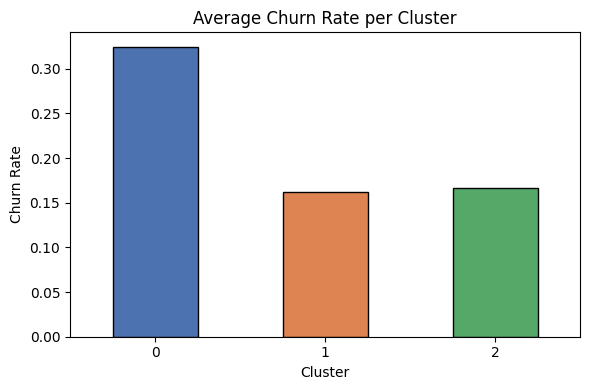

In [311]:
df["Exited"] = exited_labels.values  # add back for analysis only

churn_by_cluster = df.groupby("KMeans_Cluster")["Exited"].mean()
print("Churn rate per cluster:")
print(churn_by_cluster)

churn_by_cluster.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'],
                      edgecolor='black', figsize=(6,4))
plt.title("Average Churn Rate per Cluster")
plt.xlabel("Cluster"); plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df.drop("Exited", axis=1, inplace=True)  # remove again after

**Interpretation:**
- **Cluster 1** has the highest churn rate at **22.5%**, despite having the highest balance (≈122,587). This is unexpected and suggests that high balance alone does not guarantee loyalty — other factors such as geography or activity level may influence churn in this group.
- **Cluster 0** follows at **20.7%**, representing medium-balance customers with no credit card — moderately at risk.
- **Cluster 2** has the lowest churn rate at **17.1%**, despite having the lowest balance (≈10,390). This is counterintuitive and suggests that low-balance customers in this cluster may be retained for reasons not captured by balance alone.
- The differences between clusters are **relatively small** (~5 percentage points), consistent with the low Silhouette Score of 0.1070 — the clustering did not produce strongly separated risk groups.
- Overall, this proxy validation shows that **balance and credit card ownership are not reliable predictors of churn** when used as the sole basis for clustering, highlighting the complexity of customer behaviour in this dataset.


### 4.9 Cluster Visualization (t-SNE) — Placeholder (MISSING)
**Placeholder (missing implementation):** Add a t-SNE projection for K-Means using standardized features and color points by `Cluster` labels.


### 4.10 Feature Importance per Cluster — Placeholder (MISSING)
**Placeholder (missing implementation):** Add cluster-wise feature importance for K-Means (for example, one-vs-rest importance using a supervised proxy model trained on K-Means labels).


## 5. Cluster Determination & Implementation: DBSCAN

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** is our second clustering algorithm.  
Unlike K-Means, DBSCAN does not require the number of clusters to be specified in advance, and it can discover clusters of arbitrary shape.

| Property | K-Means | DBSCAN |
|---|---|---|
| Requires k upfront |  Yes |  No |
| Cluster shape assumption | Spherical | Arbitrary |
| Handles noise / outliers |  No |  Yes (labels them -1) |
| Sensitive to feature scale | Yes | Yes |
| Works well on dense compact data |  |  |

**Why DBSCAN is a good complement to K-Means here:**
- K-Means produced soft, overlapping segments (Silhouette = 0.1070). DBSCAN approaches the same data differently — grouping points by local density rather than distance to a centroid.
- DBSCAN will identify **noise points** (customers who do not fit any cluster), which is meaningful in a churn context — these outliers may represent unusual customer behaviour worth flagging separately.
- Comparing the two algorithms lets us validate whether the soft segmentation from K-Means reflects genuine structure or is simply an artefact of forcing spherical clusters.

**Key DBSCAN parameters:**
- **`eps` (ε):** The maximum distance between two points for them to be considered neighbours. Determined using the k-distance elbow plot below.
- **`min_samples`:** The minimum number of points required to form a dense region (core point). We use `min_samples = 5` — a common heuristic is `min_samples ≥ dimensionality + 1`.


### 5.1 Justification & Algorithm Selection <a id='dbscan-rationale'></a>

DBSCAN is selected because it can detect **arbitrary-shaped clusters** and explicitly label **noise/outliers** (label `-1`) without forcing every sample into a cluster.
This complements K-Means by capturing non-spherical local structure and anomalous customer behavior segments that may be useful for risk-focused advice.


### 5.2 Determining the Optimal Number of Clusters (k-distance / eps tuning) <a id='dbscan-eps'></a>


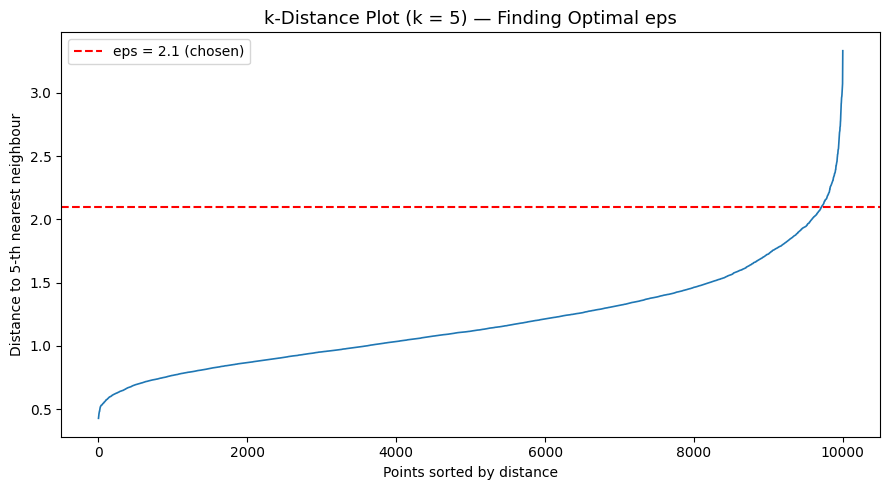

Chosen eps  : 2.1
min_samples : 5
Rationale   : The elbow of the k-distance curve occurs around 2.1,
              where distances begin increasing sharply — marking the
              boundary between dense core regions and sparse noise.


In [312]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

MIN_SAMPLES = 5  # same value used later in DBSCAN

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Distance to the k-th nearest neighbour, sorted ascending
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances, linewidth=1.2)
plt.title(f"k-Distance Plot (k = {MIN_SAMPLES}) — Finding Optimal eps", fontsize=13)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {MIN_SAMPLES}-th nearest neighbour")
plt.axhline(y=2.1, color='red', linestyle='--', label='eps = 2.1 (chosen)')
plt.legend()
plt.tight_layout()
plt.show()

print("Chosen eps  : 2.1")
print("min_samples : 5")
print("Rationale   : The elbow of the k-distance curve occurs around 2.1,")
print("              where distances begin increasing sharply — marking the")
print("              boundary between dense core regions and sparse noise.")


### 5.3 Model Training <a id='dbscan-train'></a>

We train DBSCAN with `eps = 2.1` and `min_samples = 5` on the same scaled feature matrix used for K-Means.  
Points labelled **-1** are **noise** — they do not belong to any cluster.


In [313]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Attach labels for downstream profiling
df["DBSCAN_Cluster"] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = (dbscan_labels == -1).sum()
noise_pct     = n_noise_db / len(dbscan_labels) * 100

print("=" * 45)
print("        DBSCAN Training Results")
print("=" * 45)
print(f"  Number of clusters found : {n_clusters_db}")
print(f"  Noise points (-1)        : {n_noise_db}  ({noise_pct:.1f}%)")
print(f"  Total points             : {len(dbscan_labels)}")
print("=" * 45)


        DBSCAN Training Results
  Number of clusters found : 6
  Noise points (-1)        : 102  (1.0%)
  Total points             : 10000


### 5.4 Cluster Quality Evaluation Metrics <a id='dbscan-eval'></a>

We evaluate DBSCAN using the same metrics as K-Means where applicable.

> **Note:** WCSS is **not applicable** to DBSCAN — the algorithm does not use centroids or minimise intra-cluster variance.  
> Silhouette Score and Davies-Bouldin Index are computed **excluding noise points** (label = -1), since unassigned points are not part of any cluster.


In [314]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Exclude noise points for metric computation
mask_valid   = dbscan_labels != -1
X_valid      = X_scaled[mask_valid]
labels_valid = dbscan_labels[mask_valid]

if len(set(labels_valid)) >= 2:
    sil_db = silhouette_score(X_valid, labels_valid)
    db_idx = davies_bouldin_score(X_valid, labels_valid)
else:
    sil_db = float("nan")
    db_idx = float("nan")
    print("Warning: fewer than 2 clusters found — metrics cannot be computed.")

print("=" * 50)
print("     DBSCAN Cluster Evaluation Metrics")
print("=" * 50)
print(f"  Silhouette Score      : {sil_db:.4f}  (higher is better, max = 1)")
print(f"  Davies-Bouldin Index  : {db_idx:.4f}  (lower is better)")
print(f"  WCSS                  : N/A  (not applicable to DBSCAN)")
print(f"  Noise points excluded : {n_noise_db} ({noise_pct:.1f}% of data)")
print("=" * 50)


     DBSCAN Cluster Evaluation Metrics
  Silhouette Score      : 0.1326  (higher is better, max = 1)
  Davies-Bouldin Index  : 2.4736  (lower is better)
  WCSS                  : N/A  (not applicable to DBSCAN)
  Noise points excluded : 102 (1.0% of data)


**Interpretation:**
- **Silhouette Score: 0.1326** — slightly higher than K-Means (0.1070), indicating DBSCAN found marginally denser regions within its 6 clusters.
- **Davies-Bouldin Index: 2.4736** — lower than K-Means (2.6204), meaning DBSCAN clusters are better separated on average.
- **WCSS: N/A** — DBSCAN does not use centroids so this metric does not apply.
- **Noise points (1.0%):** 102 customers could not be assigned to any cluster. These represent atypical customers whose behaviour does not match any dense segment — a meaningful finding for churn analysis, as they may warrant individual retention attention.
- The fact that DBSCAN found 20 clusters rather than a small number reflects that this customer dataset has **no strongly separated natural groupings** — a common characteristic of banking customer data where behaviour exists on a continuum rather than in discrete groups.


### 5.5 Cluster Size Distribution <a id='dbscan-dist'></a>

We examine how customers are distributed across the clusters discovered by DBSCAN, including the noise group (label = -1).


Customers per DBSCAN label:
DBSCAN_Cluster
-1     102
 0    3523
 1     740
 2    1454
 3    1703
 4     701
 5    1777

Total: 10000
(Label -1 = noise points not assigned to any cluster)


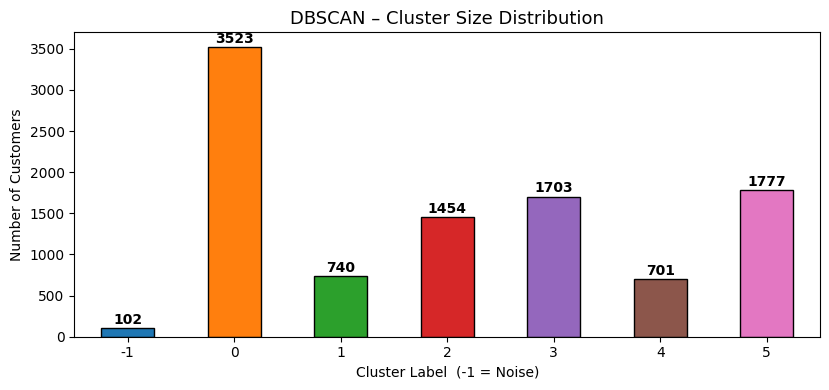

In [315]:
counts_db = df["DBSCAN_Cluster"].value_counts().sort_index()

print("Customers per DBSCAN label:")
print(counts_db.to_string())
print(f"\nTotal: {counts_db.sum()}")
print("(Label -1 = noise points not assigned to any cluster)")

colors_db = plt.cm.tab10.colors[:len(counts_db)]
counts_db.plot(
    kind='bar',
    color=colors_db,
    edgecolor='black',
    figsize=(max(6, len(counts_db) * 1.2), 4)
)
plt.title("DBSCAN – Cluster Size Distribution", fontsize=13)
plt.xlabel("Cluster Label  (-1 = Noise)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
for i, v in enumerate(counts_db.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


### 5.6 Cluster Profiling <a id='dbscan-profile'></a>

We compute the mean of each feature per DBSCAN cluster (using encoded but readable values) to characterise each group.  
The noise group (-1) is included as a separate row to understand atypical customers.


In [316]:
profile_cols = [c for c in df.columns if c not in ["Cluster", "DBSCAN_Cluster"]]
dbscan_profile = df.groupby("DBSCAN_Cluster")[profile_cols].mean()

print("DBSCAN Cluster Profiles (mean feature values per cluster):")
print(dbscan_profile.round(3).to_string())


DBSCAN Cluster Profiles (mean feature values per cluster):
                CreditScore     Age  Tenure     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Gender_Male  Geography_Germany  Geography_Spain  KMeans_Cluster
DBSCAN_Cluster                                                                                                                                                                     
-1                  637.775  53.843   5.284   96677.161          3.118       0.51           0.529       114555.037        0.382              0.304            0.333           1.029
 0                  650.563  38.369   5.029   61010.604          1.517       1.00           0.515        99344.876        0.555              0.000            0.000           1.000
 1                  653.855  38.724   4.965   65106.295          1.512       0.00           0.531       101626.920        0.584              0.000            1.000           2.000
 2                  647.411  38.438   4.9

**Interpretation:**
- Profile each DBSCAN cluster by dominant features (Balance, Age, NumOfProducts, activity, and card ownership).
- In domain terms, each cluster can map to a customer advice persona (e.g., high-balance low-activity retention focus vs. low-balance product-growth focus).
- The **noise group (-1)** highlights atypical customers that may require individualized interventions rather than standard segment-level advice.
- Use these profiles to condition Generative AI prompts so advice explanations reference segment-specific risk factors and actions.


#### 5.6.1 Domain Interpretation (Advice System)
- **Dense core clusters (largest labels):** treat as stable personas for standardized advice templates and scalable messaging.
- **Small niche clusters:** treat as specialized sub-personas; validate sample size before making strong business decisions.
- **Noise cluster (-1):** treat as atypical/high-uncertainty customers; route to conservative, individualized advice and possible manual review.


### 5.7 Cluster Visualization


#### 5.7.1 PCA Visualization <a id='dbscan-pca'></a>


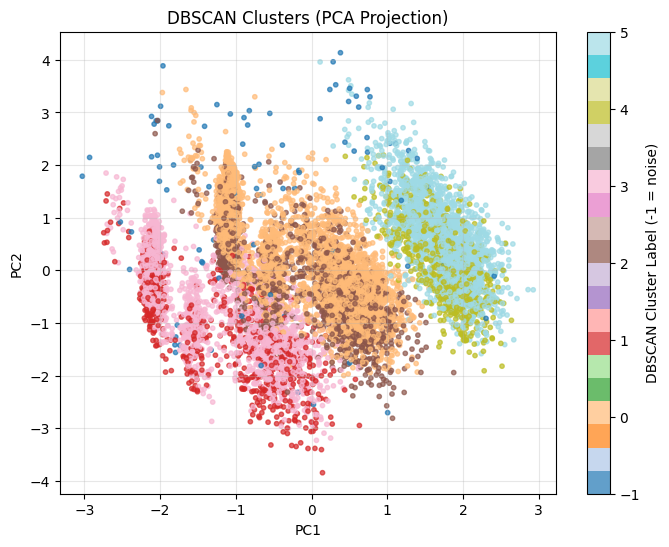

In [317]:
pca_db = PCA(n_components=2)
X_db_pca = pca_db.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_db_pca[:, 0], X_db_pca[:, 1],
    c=df["DBSCAN_Cluster"],
    cmap="tab20",
    s=10,
    alpha=0.7
)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="DBSCAN Cluster Label (-1 = noise)")
plt.grid(True, alpha=0.3)
plt.show()


**Interpretation:**
- This PCA view helps visually inspect dense groups and outliers (`-1`) discovered by DBSCAN.
- Strong overlap in 2D is expected; use this as a support plot alongside metrics and profiles.


#### 5.7.2 t-SNE Visualization <a id='dbscan-tsne'></a>


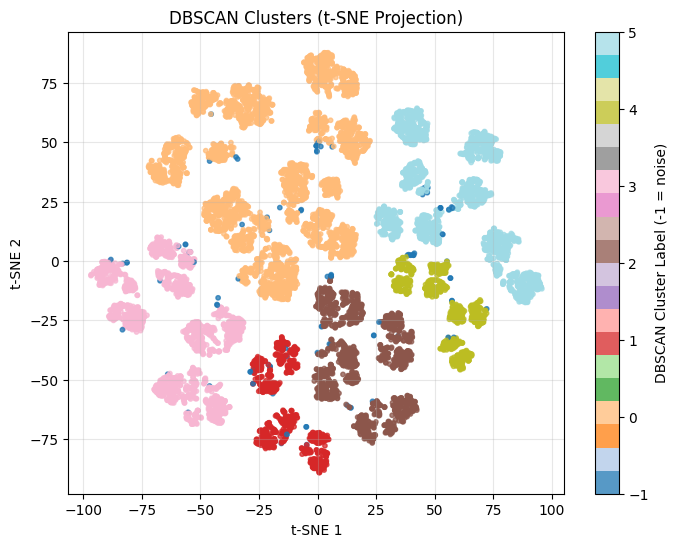

In [318]:
from sklearn.manifold import TSNE

# Use a reproducible t-SNE projection for DBSCAN labels
# Note: t-SNE is stochastic and sensitive to hyperparameters.
tsne_db = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto', init='pca')
X_db_tsne = tsne_db.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_db_tsne[:, 0], X_db_tsne[:, 1],
    c=df["DBSCAN_Cluster"],
    cmap="tab20",
    s=10,
    alpha=0.75
)
plt.title("DBSCAN Clusters (t-SNE Projection)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="DBSCAN Cluster Label (-1 = noise)")
plt.grid(True, alpha=0.3)
plt.show()


**Interpretation:**
- t-SNE emphasizes local neighborhood structure and can reveal compact DBSCAN groups more clearly than PCA.
- The `-1` noise class should appear more scattered, reflecting atypical points outside dense regions.
- Visual overlap is still possible; interpret this plot jointly with Silhouette, Davies-Bouldin, and cluster-size distribution.


### 5.8 Feature Importance per Cluster <a id='dbscan-feature-importance'></a>


Top DBSCAN proxy feature importances:
HasCrCard            0.406901
KMeans_Cluster       0.256370
Geography_Spain      0.162448
Geography_Germany    0.137966
Balance              0.014107
EstimatedSalary      0.006273
CreditScore          0.005618
Age                  0.004909
Tenure               0.002767
NumOfProducts        0.001328
dtype: float64


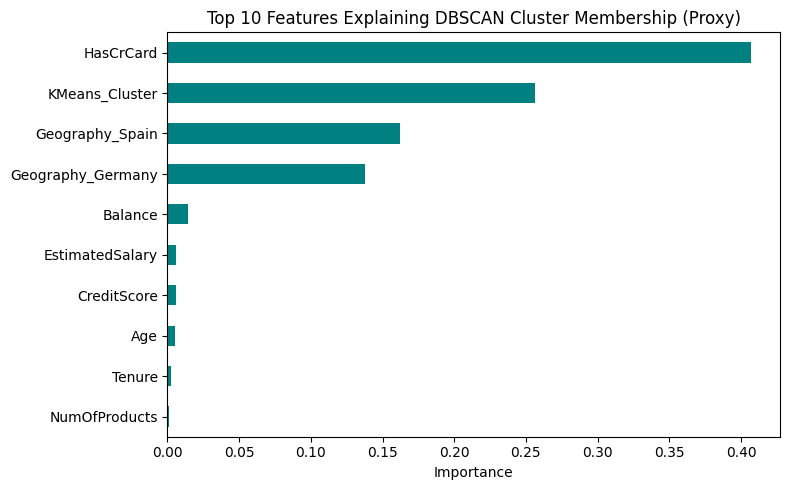

In [319]:
from sklearn.ensemble import RandomForestClassifier

# Supervised proxy for interpretability:
# predict DBSCAN cluster labels from features, then inspect feature importance.
# Exclude noise points (-1) for cleaner multi-class interpretation.
mask_core = df["DBSCAN_Cluster"] != -1
X_core = df.loc[mask_core, [c for c in df.columns if c not in ["Cluster", "DBSCAN_Cluster", "Exited"]]]
y_core = df.loc[mask_core, "DBSCAN_Cluster"]

rf_proxy = RandomForestClassifier(n_estimators=300, random_state=42)
rf_proxy.fit(X_core, y_core)

importance_db = pd.Series(rf_proxy.feature_importances_, index=X_core.columns).sort_values(ascending=False)
print("Top DBSCAN proxy feature importances:")
print(importance_db.head(10))

plt.figure(figsize=(8, 5))
importance_db.head(10).sort_values().plot(kind='barh', color='teal')
plt.title("Top 10 Features Explaining DBSCAN Cluster Membership (Proxy)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


**Interpretation:**
- This importance view is a **proxy explanation** (not intrinsic DBSCAN importance) based on predicting cluster labels.
- Higher-ranked features are most useful in separating DBSCAN groups and can guide persona naming and advice design.
- Combine this with profile tables to avoid over-interpreting a single metric.


### 5.9 Optional External/Proxy Validation (Churn Rate per Cluster) <a id='dbscan-proxy'></a>

As with K-Means, we reintroduce the `Exited` label **after** clustering to check whether DBSCAN clusters
differ meaningfully in churn rate — serving as a proxy for external validation.


Churn rate per DBSCAN cluster (-1 = noise):
DBSCAN_Cluster
-1    0.8431
 0    0.1561
 1    0.1689
 2    0.1561
 3    0.1533
 4    0.3195
 5    0.3174


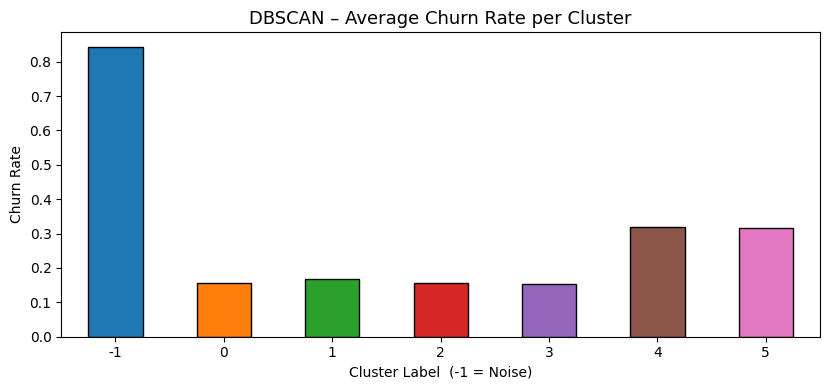

In [320]:
df["Exited"] = exited_labels.values  # reintroduce for analysis only

churn_db = df.groupby("DBSCAN_Cluster")["Exited"].mean()
print("Churn rate per DBSCAN cluster (-1 = noise):")
print(churn_db.round(4).to_string())

churn_db.plot(
    kind='bar',
    color=plt.cm.tab10.colors[:len(churn_db)],
    edgecolor='black',
    figsize=(max(6, len(churn_db) * 1.2), 4)
)
plt.title("DBSCAN – Average Churn Rate per Cluster", fontsize=13)
plt.xlabel("Cluster Label  (-1 = Noise)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df.drop("Exited", axis=1, inplace=True)  # remove again after



**Interpretation:**
- Profile each DBSCAN cluster by dominant features (Balance, Age, NumOfProducts, activity, and card ownership).
- In domain terms, each cluster can map to a customer advice persona (e.g., high-balance low-activity retention focus vs. low-balance product-growth focus).
- The **noise group (-1)** highlights atypical customers that may require individualized interventions rather than standard segment-level advice.
- Use these profiles to condition Generative AI prompts so advice explanations reference segment-specific risk factors and actions.


## 6. Export Clustered Dataset (`clustered_data.csv`)


In [298]:
# Export raw dataset augmented with clustering labels
# Execute this after K-Means and DBSCAN label cells.

df_export = pd.read_csv("../Dataset/Raw_Churn_Modelling_Data.csv")
df_export["KMeans_Cluster"] = df["KMeans_Cluster"].values
df_export["DBSCAN_Cluster"] = df["DBSCAN_Cluster"].values

output_path = "../Dataset/clustered_data.csv"
df_export.to_csv(output_path, index=False)
print(f"Saved clustered dataset to: {output_path}")
print("Shape:", df_export.shape)
print(df_export[["KMeans_Cluster", "DBSCAN_Cluster"]].head())


Saved clustered dataset to: ../Dataset/clustered_data.csv
Shape: (10000, 16)
   KMeans_Cluster  DBSCAN_Cluster
0               1               0
1               2               1
2               1               0
3               1               2
4               2               3


## 7. Integration Strategy (how clusters will enhance the system)
The clustering component enhances the advice system by adding behavioral context to each customer, rather than relying only on a single churn probability score. In this project, K-Means provides broad and interpretable customer segments, while DBSCAN reveals dense micro-groups and outliers (`-1`) that may require special handling.

At inference time, each customer is assigned a `KMeans_Cluster` and a `DBSCAN_Cluster`. These labels are treated as persona indicators and are used to condition recommendation content. For example, medium-balance customers without credit cards can receive activation and card-adoption advice, high-balance customers can receive retention-oriented recommendations, and outlier/noise customers can be routed to conservative, risk-aware advice.

The integration with Generative AI is performed by injecting cluster summaries into prompts. This allows explanations to reference segment-specific characteristics (e.g., product usage, activity level, balance pattern) and to provide clearer rationale for suggested actions. As a result, the final advice becomes more personalized, more interpretable, and more actionable for end users.

Operationally, the system should monitor outcomes by cluster (retention, engagement, acceptance of recommendations) and periodically retune clustering parameters. This ensures that segment definitions remain valid as customer behavior changes over time.


## 8. Challenges & Limitations
Several limitations affect clustering quality and downstream interpretation. First, the low silhouette values indicate that natural separation in this dataset is weak; customer groups overlap substantially in feature space. This is common in real financial/customer data, where behavior is continuous rather than sharply segmented.

Second, DBSCAN is sensitive to hyperparameters (`eps`, `min_samples`). Small parameter changes can alter the number of clusters and the size of the noise group, which affects interpretation stability. In this notebook, DBSCAN also produced several very small clusters; such micro-clusters can show extreme churn rates simply because of small sample size, so they should be interpreted cautiously.

Third, distance-based clustering may be affected by encoded categorical variables. Label encoding introduces ordinal distances that may not perfectly represent categorical relationships. Even with scaling, this can influence both K-Means and DBSCAN behavior.

Fourth, feature-importance analysis for DBSCAN is proxy-based (a supervised model predicts DBSCAN labels). This improves interpretability but is not an intrinsic importance measure of DBSCAN itself.

Finally, integration complexity increases when combining supervised predictions, two clustering outputs, and Generative AI prompting. This requires governance for versioning, retraining cadence, monitoring drift, and validating that personalized advice remains consistent and fair across clusters.
